# Notebook 6: Financial Performance Analysis

## Objective

The purpose of this notebook is to analyze how company financial fundamentals relate to historical stock performance.

Using the integrated dataset created in Notebook 5, this notebook investigates whether factors such as profitability, valuation, revenue, and company size help explain differences in stock returns among five major technology companies.

## Business Questions

1. Do companies with higher profit margins achieve higher stock returns?
2. Do larger companies generate higher stock returns?
3. Are companies with higher P/E ratios valued differently by the market?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/stock_data_complete.csv")

df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,Company,Sector,Market Cap,Forward PE,EPS,Revenue,Net Income,Profit Margin,Return on Equity
0,2020-01-02,72.333878,75.087502,75.150002,73.797501,74.059998,135480400,AAPL,Apple Inc.,Technology,4138015391744,29.320671,8.25,451442016256,122575003648,0.27152,1.41471
1,2020-01-03,71.630661,74.357498,75.144997,74.125000,74.287498,146322800,AAPL,Apple Inc.,Technology,4138015391744,29.320671,8.25,451442016256,122575003648,0.27152,1.41471
2,2020-01-06,72.201416,74.949997,74.989998,73.187500,73.447502,118387200,AAPL,Apple Inc.,Technology,4138015391744,29.320671,8.25,451442016256,122575003648,0.27152,1.41471
3,2020-01-07,71.861855,74.597504,75.224998,74.370003,74.959999,108872000,AAPL,Apple Inc.,Technology,4138015391744,29.320671,8.25,451442016256,122575003648,0.27152,1.41471
4,2020-01-08,73.017845,75.797501,76.110001,74.290001,74.290001,132079200,AAPL,Apple Inc.,Technology,4138015391744,29.320671,8.25,451442016256,122575003648,0.27152,1.41471


In [3]:
company_df = df.groupby("Ticker").first().reset_index()

company_df

,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,Company,Sector,Market Cap,Forward PE,EPS,Revenue,Net Income,Profit Margin,Return on Equity
0,AAPL,2020-01-02,72.333878,75.087502,75.150002,73.797501,74.059998,135480400,Apple Inc.,Technology,4138015391744,29.320671,8.25,451442016256,122575003648,0.27152,1.41471
1,AMZN,2020-01-02,94.900497,94.900497,94.900497,93.207497,93.750000,80580000,"Amazon.com, Inc.",Consumer Cyclical,2583212326912,24.304340,7.59,742775980032,90797998080,0.12224,0.24285
2,GOOGL,2020-01-02,67.832497,68.433998,68.433998,67.324501,67.420502,27278000,Alphabet Inc.,Communication Services,4315439693824,24.300047,13.12,422498009088,160207994880,0.37919,0.38885
3,MSFT,2020-01-02,151.829529,160.619995,160.729996,158.330002,158.779999,22622100,Microsoft Corporation,Technology,2737898258432,19.029018,16.81,318272995328,125215997952,0.39342,0.34014
4,NVDA,2020-01-02,5.963803,5.997750,5.997750,5.918000,5.968750,237536000,NVIDIA Corporation,Technology,4722368446464,15.274478,6.53,253491003392,159612993536,0.62966,1.14288


# Analysis 1
### Business Question

Do companies with higher profit margins achieve higher stock returns?

In [4]:
returns = []

for ticker in df["Ticker"].unique():

    stock = df[df["Ticker"] == ticker]

    start_price = stock.iloc[0]["Adj Close"]
    end_price = stock.iloc[-1]["Adj Close"]

    total_return = ((end_price - start_price) / start_price) * 100

    returns.append({
        "Ticker": ticker,
        "Return (%)": total_return
    })

returns_df = pd.DataFrame(returns)

In [5]:
analysis1 = company_df.merge(returns_df, on="Ticker")

analysis1

,Ticker,Date,Adj Close,Close,High,Low,Open,Volume,Company,Sector,Market Cap,Forward PE,EPS,Revenue,Net Income,Profit Margin,Return on Equity,Return (%)
0,AAPL,2020-01-02,72.333878,75.087502,75.150002,73.797501,74.059998,135480400,Apple Inc.,Technology,4138015391744,29.320671,8.25,451442016256,122575003648,0.27152,1.41471,244.002318
1,AMZN,2020-01-02,94.900497,94.900497,94.900497,93.207497,93.750000,80580000,"Amazon.com, Inc.",Consumer Cyclical,2583212326912,24.304340,7.59,742775980032,90797998080,0.12224,0.24285,131.178977
2,GOOGL,2020-01-02,67.832497,68.433998,68.433998,67.324501,67.420502,27278000,Alphabet Inc.,Communication Services,4315439693824,24.300047,13.12,422498009088,160207994880,0.37919,0.38885,177.619681
3,MSFT,2020-01-02,151.829529,160.619995,160.729996,158.330002,158.779999,22622100,Microsoft Corporation,Technology,2737898258432,19.029018,16.81,318272995328,125215997952,0.39342,0.34014,174.359286
4,NVDA,2020-01-02,5.963803,5.997750,5.997750,5.918000,5.968750,237536000,NVIDIA Corporation,Technology,4722368446464,15.274478,6.53,253491003392,159612993536,0.62966,1.14288,2148.392944


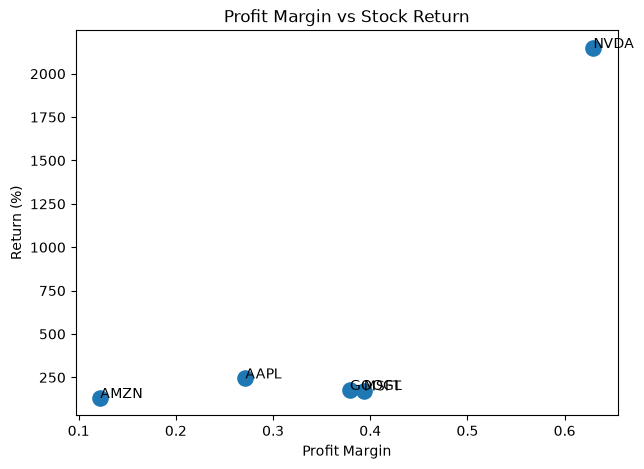

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(
    analysis1["Profit Margin"],
    analysis1["Return (%)"],
    s=120
)

for i in range(len(analysis1)):
    plt.text(
        analysis1["Profit Margin"].iloc[i],
        analysis1["Return (%)"].iloc[i],
        analysis1["Ticker"].iloc[i]
    )

plt.title("Profit Margin vs Stock Return")
plt.xlabel("Profit Margin")
plt.ylabel("Return (%)")

plt.show()

## Analysis
The visualization suggests a moderate positive relationship between profit margin and cumulative stock returns. NVIDIA recorded both the highest profit margin and the highest stock return by a significant margin, indicating that strong operational profitability may have contributed to its exceptional market performance.

However, the relationship is not perfectly linear. Microsoft and Google report similar profit margins but achieved different stock returns, while Apple generated higher returns than Google despite having a lower profit margin. Amazon has both the lowest profit margin and the lowest overall return, which aligns with the general trend.

Overall, the results indicate that profitability appears to influence stock performance, but it is not the only determining factor. Market conditions, future growth expectations, and industry-specific developments also play important roles in driving returns.

# Analysis 2
### Business Question

Do larger companies generate higher stock returns?

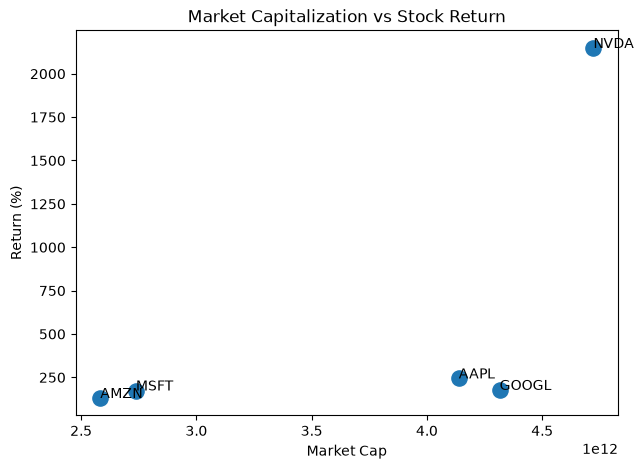

In [7]:
plt.figure(figsize=(7,5))

plt.scatter(
    analysis1["Market Cap"],
    analysis1["Return (%)"],
    s=120
)

for i in range(len(analysis1)):
    plt.text(
        analysis1["Market Cap"].iloc[i],
        analysis1["Return (%)"].iloc[i],
        analysis1["Ticker"].iloc[i]
    )

plt.title("Market Capitalization vs Stock Return")
plt.xlabel("Market Cap")
plt.ylabel("Return (%)")

plt.show()

## Analysis

The scatter plot shows little evidence of a clear positive relationship between market capitalization and stock returns. Although NVIDIA has both the largest market capitalization and the highest cumulative return, the remaining companies do not follow a consistent pattern.

For example, Apple and Google have similarly large market capitalizations but generated substantially lower returns than NVIDIA. Meanwhile, Amazon and Microsoft have smaller market capitalizations than Apple yet produced returns of similar magnitude.

These findings suggest that company size alone is not a reliable predictor of investment performance. Other factors, such as business growth, industry trends and investor sentiment, are likely to have a greater influence on long-term stock returns.

# Analysis 3
### Business Question

Are companies with higher Forward P/E ratios valued differently by investors?

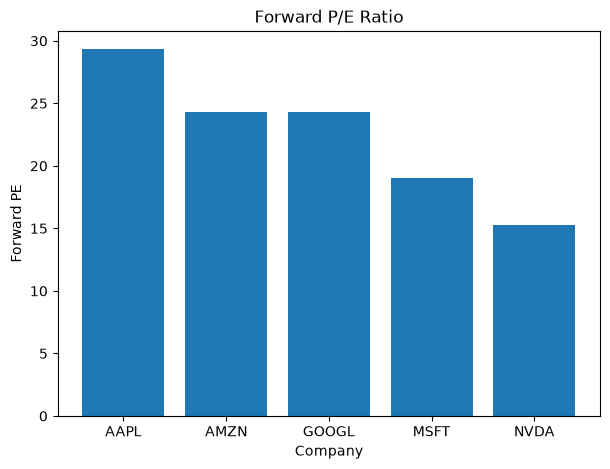

In [8]:
plt.figure(figsize=(7,5))

plt.bar(
    analysis1["Ticker"],
    analysis1["Forward PE"]
)

plt.title("Forward P/E Ratio")
plt.xlabel("Company")
plt.ylabel("Forward PE")

plt.show()

## Analysis
Apple has the highest Forward P/E ratio among the five companies, indicating that investors are willing to pay the largest premium for its future earnings. This generally reflects strong market confidence in Apple's future growth potential, profitability, and stable business model.

Microsoft, Amazon and Google have relatively similar Forward P/E ratios, suggesting that the market expects steady long-term growth from these companies. NVIDIA has the lowest Forward P/E ratio despite producing the strongest stock returns over the period. This may indicate that although NVIDIA has experienced exceptional growth, its future earnings expectations are considered more reasonably priced relative to its current valuation.

Overall, the chart demonstrates that market valuation is influenced not only by historical stock performance but also by investors' expectations of future earnings.